In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment setup completed successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Environment setup completed successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


# **Loading The Dataset**

In [3]:
from google.colab import files
uploaded=files.upload()

Saving Customer_Segmentation_py.csv to Customer_Segmentation_py.csv


In [4]:
df=pd.read_csv('Customer_Segmentation_py.csv')

In [7]:
# Initial Data Inspection

print("Dataframe Shape:")

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataframe Shape:
Dataset Shape:
(113036, 18)

Column Names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

First 5 Rows:


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418



Data Types:
Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object


In [9]:
#Data Quality Check

print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


,0
Date,0
Day,0
Month,0
Year,0
Customer_Age,0
Age_Group,0
Customer_Gender,0
Country,0
State,0
Product_Category,0



Duplicate Rows:
1000


In [10]:
# Inspect duplicate records

duplicates = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:", len(duplicates))

display(duplicates.head(10))

# Outcome: Data Quality Finding: The dataset contained 1,000 exact duplicate records.
# Since these rows were identical across all available fields, they were treated as redundant records
# and removed to prevent duplicated transactions from inflating sales, revenue, profit, and other aggregated metrics.

Total rows involved in duplicate groups: 1993


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
1020,19/12/2013,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1021,19/12/2013,19,December,2013,22,Youth (<25),M,Australia,New South Wales,Accessories,Bike Stands,All-Purpose Bike Stand,9,59,159,714,531,1245
1090,30/09/2015,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1091,30/09/2015,30,September,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,5,4,10,20,20,40
1092,24/10/2013,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
1093,24/10/2013,24,October,2013,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,2,4,10,8,8,16
1094,24/10/2015,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8
1095,24/10/2015,24,October,2015,42,Adults (35-64),F,Australia,Victoria,Accessories,Bottles and Cages,Mountain Bottle Cage,1,4,10,4,4,8
1192,15/01/2016,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57
1193,15/01/2016,15,January,2016,42,Adults (35-64),M,France,Seine Saint Denis,Accessories,Bottles and Cages,Water Bottle - 30 oz.,14,2,5,29,28,57


In [11]:
# Removing exact duplicate rows

df_clean = df.drop_duplicates().copy()

print("Original number of rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicate rows removed:", len(df) - len(df_clean))

Original number of rows: 113036
Rows after removing duplicates: 112036
Duplicate rows removed: 1000


# **Descriptive statistics**

In [12]:
# Building a DataFrame where each row represents one numerical variable and each column represents a statistic.

numeric_cols = df_clean.select_dtypes(include=np.number).columns

summary_stats = pd.DataFrame({
    "Mean": df_clean[numeric_cols].mean(),
    "Median": df_clean[numeric_cols].median(),
    "Mode": df_clean[numeric_cols].mode().iloc[0],
    "Standard Deviation": df_clean[numeric_cols].std()
})

display(summary_stats.round(2))

,Mean,Median,Mode,Standard Deviation
Day,15.67,16.0,24,8.78
Year,2014.40,2014.0,2016,1.27
Customer_Age,35.92,35.0,31,11.02
Order_Quantity,11.90,10.0,1,9.56
Unit_Cost,267.82,9.0,2,550.22
Unit_Price,453.85,25.0,5,922.75
Profit,286.04,103.0,3,454.85
Cost,471.10,112.0,1252,886.97
Revenue,757.14,226.0,35,1312.06


# **Time series analysis:**

In [13]:
# Convert Date column to datetime format

df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    dayfirst=True
)

print("Date column converted successfully.")
print("Date range:", df_clean["Date"].min(), "to", df_clean["Date"].max())

Date column converted successfully.
Date range: 2011-01-01 00:00:00 to 2016-07-31 00:00:00


In [14]:
# Monthly Sales Trend

monthly_sales = (
    df_clean
    .set_index("Date")
    .resample("ME")["Revenue"]
    .sum()
)

display(monthly_sales.head())

,Revenue
Date,
2011-01-31,675193
2011-02-28,635179
2011-03-31,703081
2011-04-30,698782
2011-05-31,734537


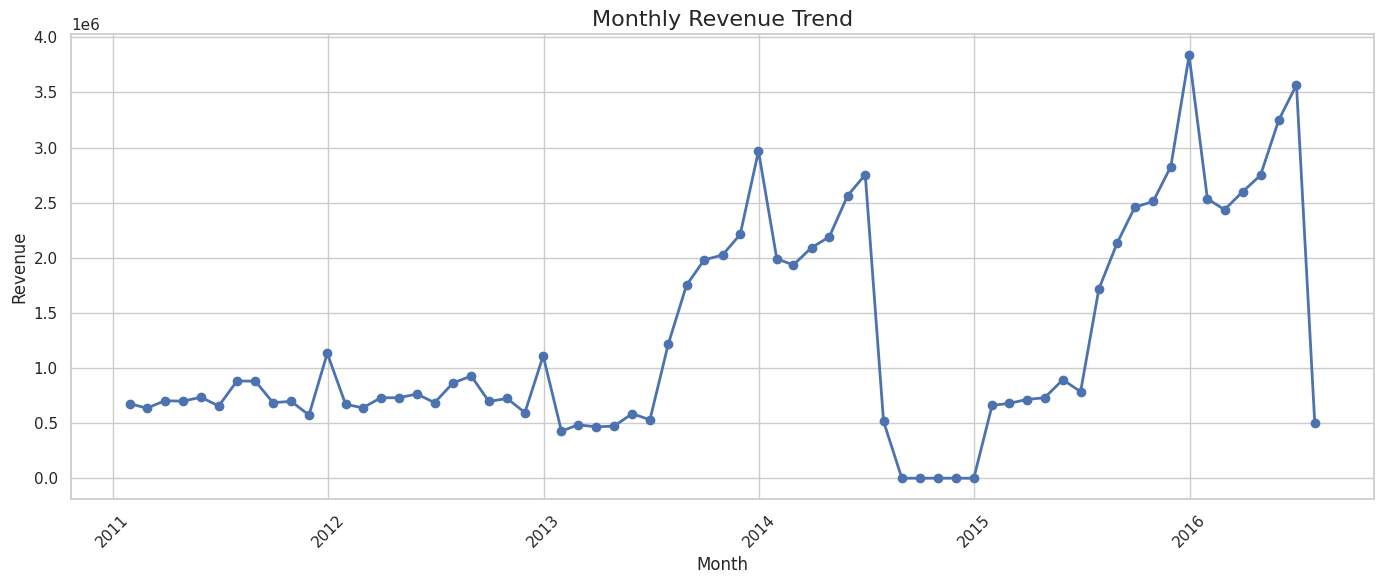

In [15]:
# Visualizing Monthly Revenue Trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
# Checking whether zero-revenue months actually contain transactions

monthly_check = (
    df_clean
    .set_index("Date")
    .resample("ME")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Revenue", "count")
    )
)

display(monthly_check[monthly_check["Revenue"] == 0])

,Revenue,Transactions
Date,,
2014-08-31,0,0
2014-09-30,0,0
2014-10-31,0,0
2014-11-30,0,0
2014-12-31,0,0


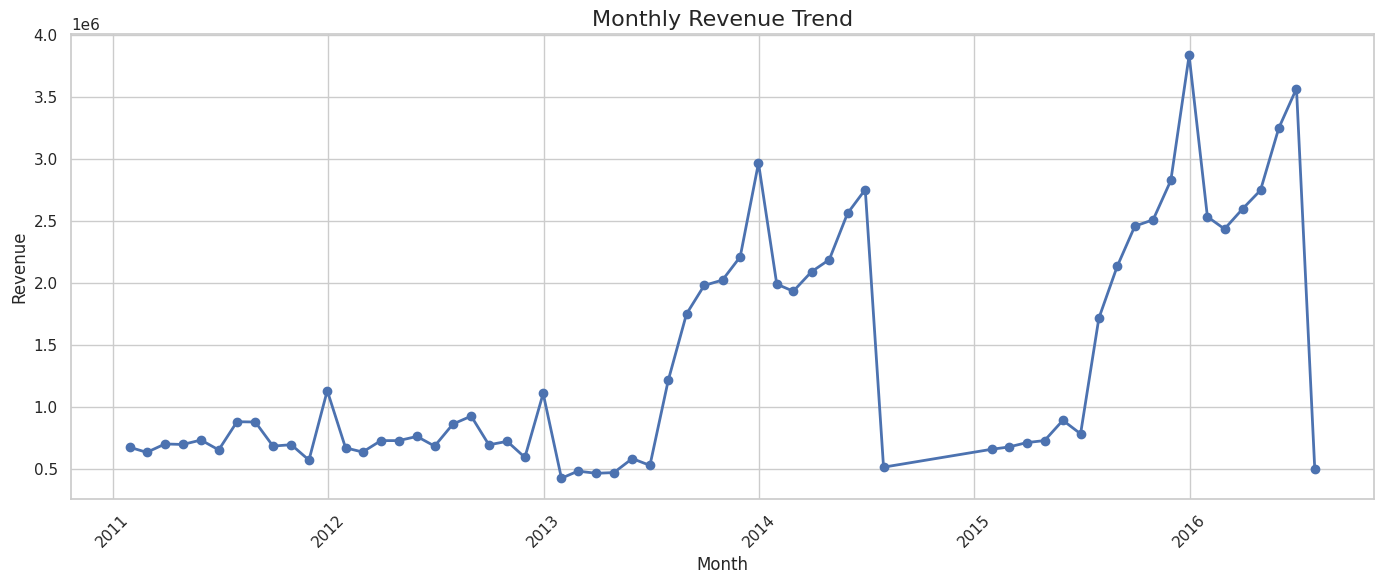

In [17]:
# Removing months with no transaction records
monthly_sales_valid = monthly_check[
    monthly_check["Transactions"] > 0
]["Revenue"]

# Visualizatoin of Monthly Revenue Trends
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales_valid.index,
    monthly_sales_valid.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Monthly revenue shows a clear upward trend over the later part of the dataset, particularly from late 2013 through 2016. Revenue remains relatively moderate during 2011–2013 before increasing substantially during 2014 and again during 2015–2016. The highest monthly revenue levels occur toward the end of the observation period, indicating stronger sales activity in the later years. The dataset also contains a five-month gap from August to December 2014 with no transaction records, so these months are treated as missing periods rather than zero-revenue months.

In [18]:
# Quarterly Sales Trend

quarterly_sales = (
    df_clean
    .set_index("Date")
    .resample("QE")["Revenue"]
    .sum()
)

display(quarterly_sales.head(10))

,Revenue
Date,
2011-03-31,2013453
2011-06-30,2088296
2011-09-30,2448010
2011-12-31,2402207
2012-03-31,2039466
2012-06-30,2178960
2012-09-30,2486753
2012-12-31,2428616
2013-03-31,1377221


In [19]:
# Checking quarterly revenue and transaction coverage

quarterly_check = (
    df_clean
    .set_index("Date")
    .resample("QE")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Revenue", "count")
    )
)

display(quarterly_check)

,Revenue,Transactions
Date,,
2011-03-31,2013453,555
2011-06-30,2088296,633
2011-09-30,2448010,732
2011-12-31,2402207,751
2012-03-31,2039466,555
2012-06-30,2178960,631
2012-09-30,2486753,730
2012-12-31,2428616,748
2013-03-31,1377221,780


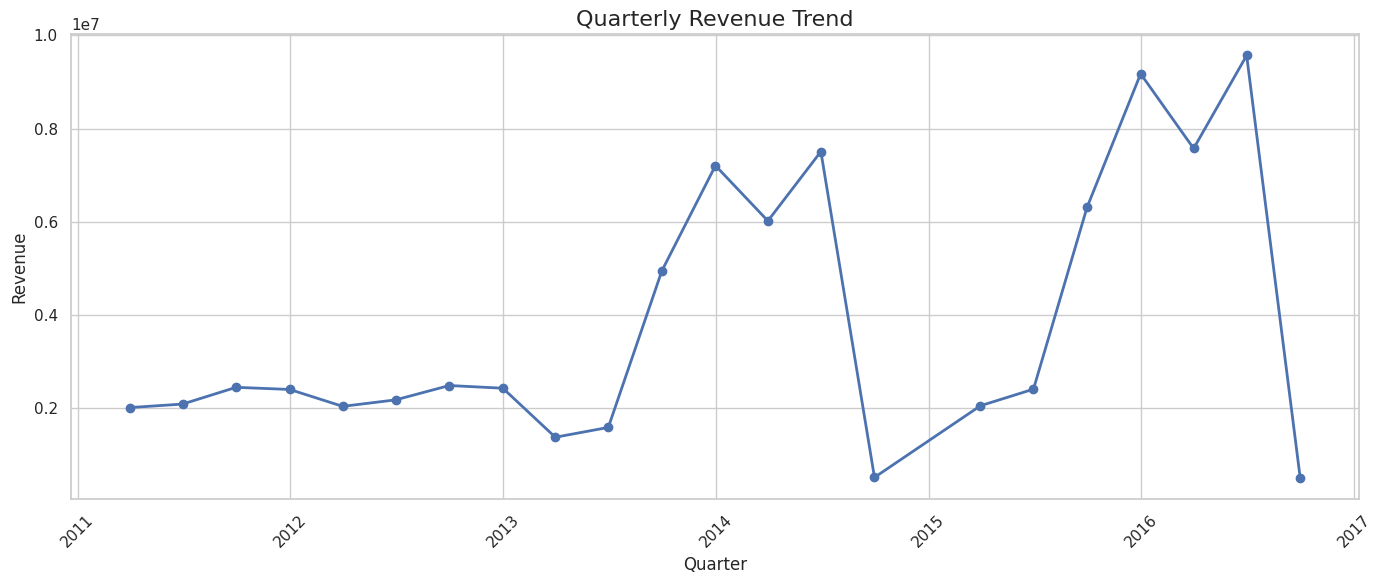

In [20]:
# Remove quarters with no transaction records
quarterly_sales_valid = quarterly_check[
    quarterly_check["Transactions"] > 0
]["Revenue"]

# Visualize Quarterly Revenue Trend
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_sales_valid.index,
    quarterly_sales_valid.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Revenue Trend", fontsize=16)
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Quarterly revenue shows relatively stable performance during 2011–2012, followed by a noticeable decline in the first half of 2013. Revenue then increases sharply from Q3 2013 and remains at substantially higher levels through 2014. A significant decline appears in Q3 2014 because the dataset contains only partial-quarter records, followed by a strong recovery in 2015. Revenue reaches its highest quarterly levels in late 2015 and the first half of 2016, indicating stronger sales activity toward the end of the observation period. Q4 2014 is excluded because the dataset contains no transaction records for that quarter, while Q3 2014 and Q3 2016 represent partial quarters.

# **Customer Demographics Analysis**

In [21]:
# Counting Customer Distribution by Age Group

age_group_counts = (
    df_clean["Age_Group"]
    .value_counts()
    .sort_index()
)

display(age_group_counts)

,count
Age_Group,
Adults (35-64),55358
Seniors (64+),719
Young Adults (25-34),38299
Youth (<25),17660


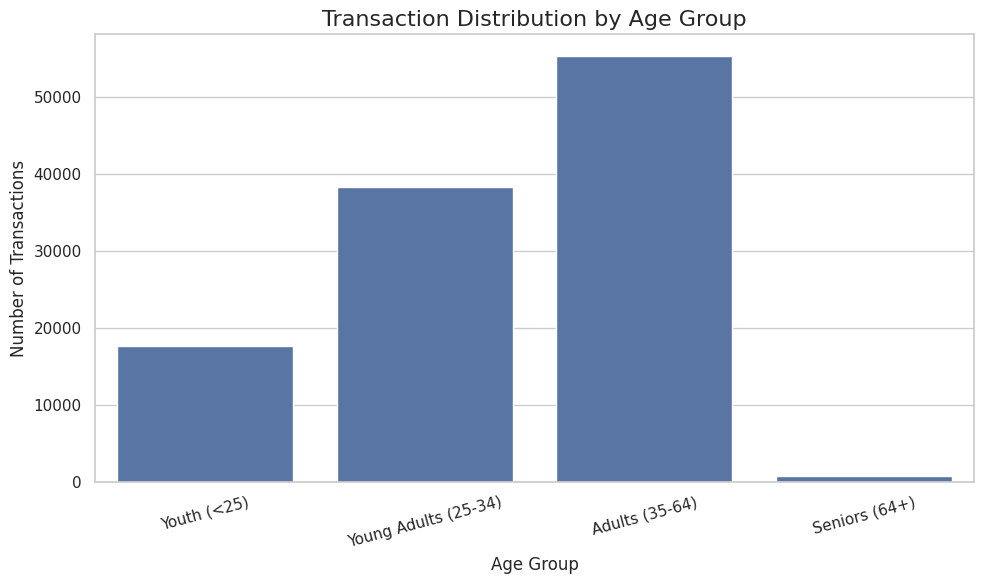

In [23]:
# Visualizing Transaction Distribution by Age Group

age_order = [
    "Youth (<25)",
    "Young Adults (25-34)",
    "Adults (35-64)",
    "Seniors (64+)"
]

age_group_counts = (
    df_clean["Age_Group"]
    .value_counts()
    .reindex(age_order)
)

# Visualize Transaction Distribution by Age Group
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Transaction Distribution by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

### Observation

Adults aged 35–64 account for the largest share of transaction records, with 55,358 transactions, followed by Young Adults aged 25–34 with 38,299 transactions. Youth under 25 account for 17,660 transactions, while Seniors aged 64 and above account for only 719. This indicates that transaction activity is concentrated primarily among adults and young adults, with comparatively limited activity among seniors.

### **Gender Analysis**

In [24]:
# Counting Transaction Distribution by Gender

gender_counts = (
    df_clean["Customer_Gender"]
    .value_counts()
)

display(gender_counts)

,count
Customer_Gender,
M,57813
F,54223


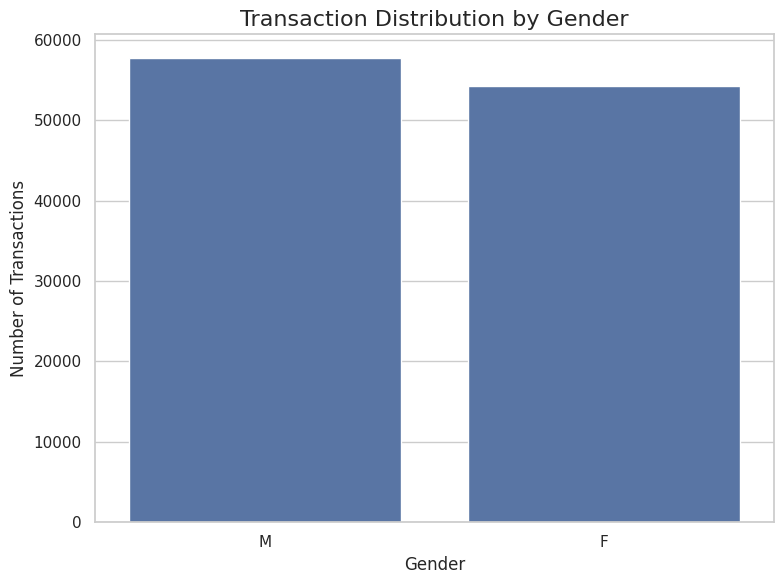

In [25]:
# Visualizing Transaction Distribution by Gender

plt.figure(figsize=(8, 6))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Transaction Distribution by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.tight_layout()

plt.show()

### Observation

Transaction activity is relatively balanced across genders, with 57,813 transactions associated with male customers and 54,223 associated with female customers. Male customers account for a slightly larger share of transaction records, but the difference is relatively small, indicating that transaction activity is not heavily concentrated in one gender group.

# **Product analysis**

In [26]:
# Top 10 Best-Selling Products by Quantity

top_products = (
    df_clean.groupby("Product")["Order_Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_products)

,Order_Quantity
Product,
Water Bottle - 30 oz.,162051
Patch Kit/8 Patches,155310
Mountain Tire Tube,100915
AWC Logo Cap,67316
"Sport-100 Helmet, Red",63652
Fender Set - Mountain,62118
"Sport-100 Helmet, Black",62072
Road Tire Tube,61305
"Sport-100 Helmet, Blue",55855


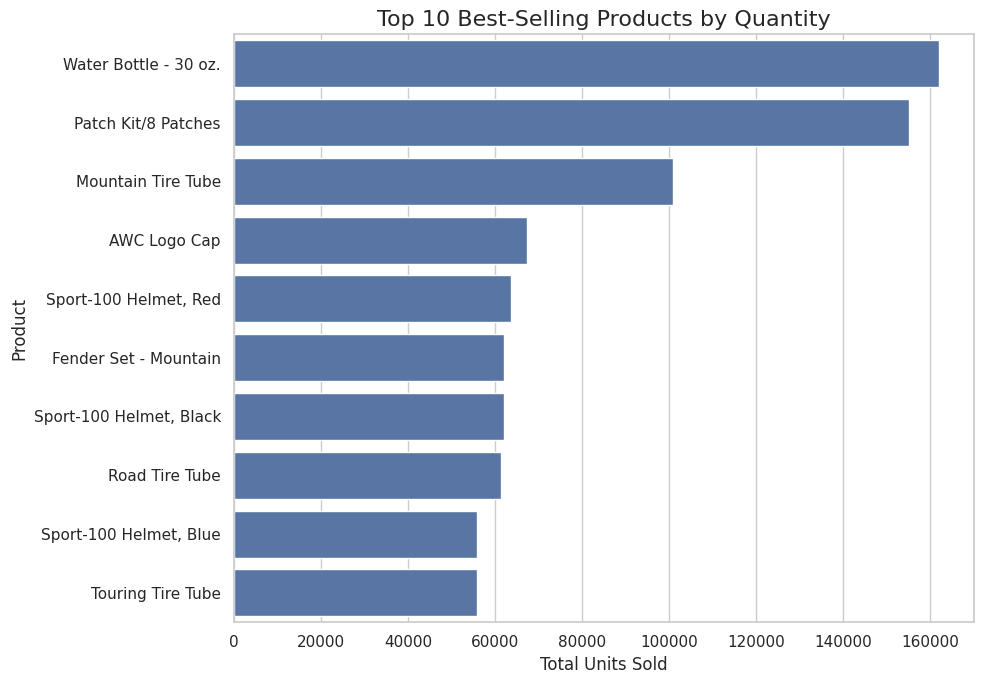

In [27]:
# Visualizing Top 10 Best-Selling Products

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products by Quantity", fontsize=16)
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

### Observation

The Water Bottle - 30 oz. is the best-selling product by quantity, with 162,051 units sold, followed by the Patch Kit/8 Patches with 155,310 units. Mountain Tire Tube ranks third with 100,915 units sold. The remaining products in the top 10 range from approximately 55,000 to 67,000 units. The results indicate that a small group of products accounts for a substantial share of total unit sales, with water bottles and patch kits showing particularly strong sales volume.

In [28]:
# Revenue by Product Category

category_revenue = (
    df_clean.groupby("Product_Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

display(category_revenue)

,Revenue
Product_Category,
Bikes,61434484
Accessories,15022766
Clothing,8369522


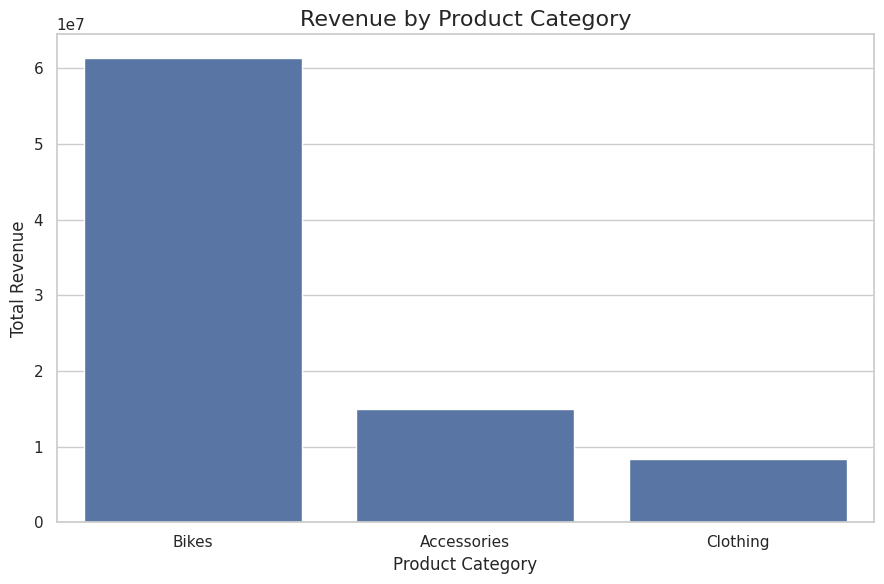

In [29]:
# Visualize Revenue by Product Category

plt.figure(figsize=(9, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.show()

### Observation

Bikes generate the highest revenue at 61.43 million, substantially exceeding Accessories at 15.02 million and Clothing at 8.37 million. Bikes account for approximately 72.4% of total revenue across the three product categories, indicating that the business is strongly dependent on its bike category for revenue generation. Accessories and Clothing contribute smaller but meaningful portions of overall revenue.

# **Heatmap**

In [30]:
# Correlation Analysis

correlation_cols = [
    "Customer_Age",
    "Order_Quantity",
    "Unit_Cost",
    "Unit_Price",
    "Profit",
    "Cost",
    "Revenue"
]

correlation_matrix = df_clean[correlation_cols].corr()

display(correlation_matrix.round(2))

,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
Customer_Age,1.00,0.03,-0.02,-0.02,0.00,-0.02,-0.01
Order_Quantity,0.03,1.00,-0.52,-0.52,-0.24,-0.34,-0.31
Unit_Cost,-0.02,-0.52,1.00,1.00,0.74,0.83,0.82
Unit_Price,-0.02,-0.52,1.00,1.00,0.75,0.83,0.82
Profit,0.00,-0.24,0.74,0.75,1.00,0.90,0.96
Cost,-0.02,-0.34,0.83,0.83,0.90,1.00,0.99
Revenue,-0.01,-0.31,0.82,0.82,0.96,0.99,1.00


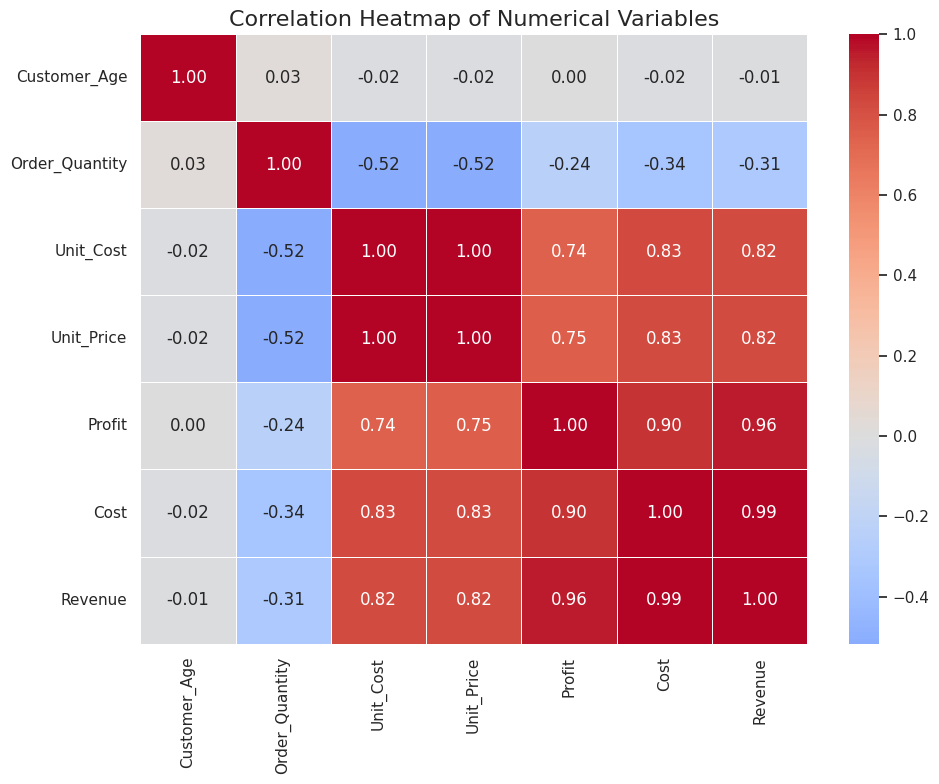

In [31]:
# Visualize Correlation Matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=16)
plt.tight_layout()

plt.show()

### Observation

The correlation analysis shows strong positive relationships among the financial variables. Revenue has a very strong correlation with Cost (0.99) and Profit (0.96), while Cost and Profit are also strongly correlated (0.90). Unit Cost and Unit Price each have strong positive correlations with Revenue (0.82). In contrast, Customer Age has almost no linear relationship with Revenue (-0.01), suggesting that age alone is not strongly associated with transaction revenue in this dataset. Order Quantity has a moderate negative correlation with Revenue (-0.31).

# **One additional non-obvious visualization**

In [32]:
# Profit Margin by Product Category

category_performance = (
    df_clean.groupby("Product_Category")[["Revenue", "Profit"]]
    .sum()
)

category_performance["Profit_Margin_%"] = (
    category_performance["Profit"]
    / category_performance["Revenue"]
    * 100
)

category_performance = category_performance.sort_values(
    "Profit_Margin_%",
    ascending=False
)

display(category_performance.round(2))

,Revenue,Profit,Profit_Margin_%
Product_Category,,,
Accessories,15022766,8807194,58.63
Clothing,8369522,2839319,33.92
Bikes,61434484,20399726,33.21


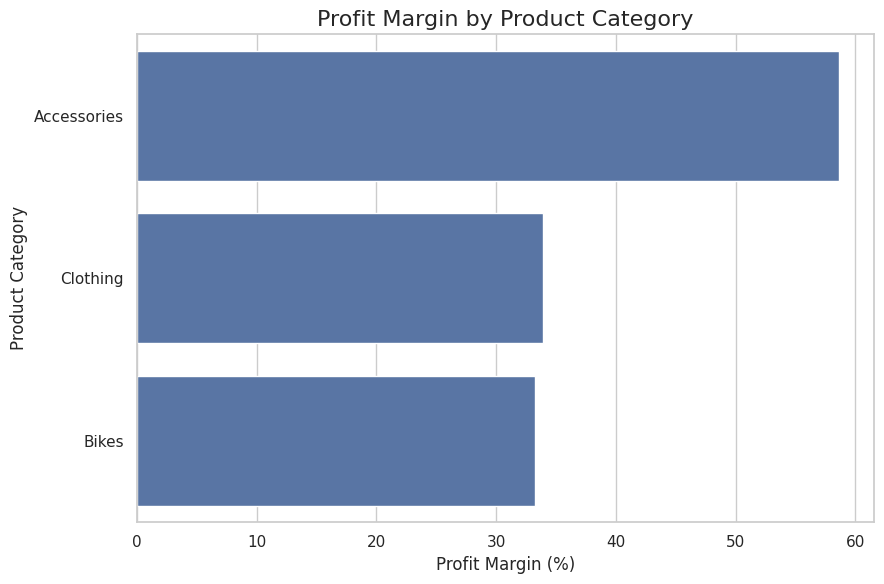

In [33]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=category_performance["Profit_Margin_%"],
    y=category_performance.index
)

plt.title("Profit Margin by Product Category", fontsize=16)
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Observation

Accessories have the highest profit margin at 58.63%, despite generating substantially less revenue than Bikes. Bikes generate the largest total revenue at 61.43 million, but their profit margin is only 33.21%, which is slightly lower than Clothing at 33.92%. This indicates that Accessories are considerably more profitable relative to their revenue, while Bikes remain the primary revenue driver. From a business perspective, the company could explore opportunities to expand high-margin Accessories sales while continuing to maintain Bikes as its core revenue category.

# Conclusion

The exploratory analysis of the retail sales dataset revealed several important patterns in sales performance and customer activity. Revenue increased substantially during the later years of the dataset, although some periods contain incomplete or missing transaction records that should be considered when comparing time-based performance. Customer transactions are concentrated primarily among Adults (35–64) and Young Adults (25–34), while transaction activity is relatively balanced across genders.

The analysis also shows that a small group of products accounts for a large volume of unit sales, with the Water Bottle - 30 oz. and Patch Kit/8 Patches ranking as the top-selling products by quantity. At the category level, Bikes are the primary revenue driver, generating 61.43 million in revenue and representing approximately 72.4% of total revenue. However, Accessories have the highest profit margin at 58.63%, considerably higher than Clothing (33.92%) and Bikes (33.21%).

Overall, the findings suggest that the business should continue supporting its strong Bike category while taking advantage of the higher profitability of Accessories and focusing marketing efforts on its most active customer segments.

## Actionable Recommendations

1. **Expand high-margin Accessories opportunities:** Since Accessories have the highest profit margin (58.63%), the business could increase their visibility through promotions, product bundles, and cross-selling alongside Bike purchases.

2. **Protect and strengthen the Bike category:** Bikes generate the majority of total revenue (61.43 million), making them the company's core revenue driver. The business should maintain strong inventory availability and continue monitoring Bike sales performance to reduce dependence-related risks.

3. **Focus customer marketing on the most active age groups:** Adults (35–64) and Young Adults (25–34) account for the largest number of transaction records. Marketing campaigns, product recommendations, and promotions could therefore prioritize these customer groups while testing targeted strategies for the comparatively underrepresented Youth and Senior segments.

In [34]:
# Saving the cleaned dataset

df_clean.to_csv("retail_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Cleaned dataset saved successfully.
Rows: 112036
Columns: 18


In [35]:
from google.colab import files

files.download("retail_sales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>